# Credit Scoring with Explainability — Statlog German Credit Dataset

**Framing:** build an interpretable credit scorecard a risk analyst could sign off on — not
just a black-box classifier — and show how it compares to a modern gradient-boosting model
on both performance and interpretability.

**Pipeline:** EDA → WOE/IV → CV-validated logistic-regression scorecard → Optuna-tuned
gradient boosting → explainability (SHAP) → fairness check → model-documentation write-up.

**Cost asymmetry:** the dataset's documentation specifies that classifying a genuinely
*bad* applicant as *good* (a missed default) costs **5x** more than classifying a *good*
applicant as *bad* (a lost-but-safe customer). This is carried through the whole notebook —
it changes which threshold and which model we'd actually deploy.

**What changed from the first pass, and why:**
- The WOE encoder is now a proper `sklearn`-compatible `Transformer` (`fit`/`transform`,
  usable in a `Pipeline`). Feature selection by IV happens *inside* the transformer's
  `fit`, so it's re-derived on every cross-validation fold instead of once on the full
  training set — the earlier version computed IV once and could leak fold information.
- Both models are evaluated with **5-fold stratified cross-validation**, not a single
  train/test split — a single 750/250 split on 1,000 rows has enough sampling noise that
  AUC differences of a point or two aren't meaningful on their own.
- LightGBM's hyperparameters are tuned with **Optuna**, optimizing mean CV AUC, rather than
  hand-picked.
- The cost-optimal decision threshold is chosen from **out-of-fold predictions on the
  training set only**, then applied once to the untouched test set — picking the threshold
  that minimizes cost *on the test set itself* would be a second, more subtle leak (you'd be
  fitting a threshold to the data you're using to report performance).
- Repeated logic (WOE/IV math, cost-weighted scoring, threshold search) is pulled into
  reusable functions instead of being copy-pasted per model.


In [1]:
import os
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

import lightgbm as lgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Configuration

All the "magic numbers" that used to be scattered through the notebook (random seed, cost
weights, PDO scorecard constants, CV fold count, IV cutoff, Optuna trial budget) live in one
`Config` object, so changing an assumption means editing one line instead of hunting through
20 cells.

In [2]:
@dataclass
class Config:
    random_state: int = 42
    test_size: float = 0.25
    n_splits: int = 5          # CV folds, used for both models
    min_iv: float = 0.02       # information-value cutoff for the scorecard
    cost_fn: float = 5.0       # cost of an actual-bad applicant predicted good
    cost_fp: float = 1.0       # cost of an actual-good applicant predicted bad
    pdo: float = 20.0          # scorecard: points to double the good:bad odds
    base_score: float = 600.0
    base_odds: float = 50.0
    n_optuna_trials: int = 25

CFG = Config()

## 1. Data loading & understanding

We use the original **Statlog (German Credit Data)** set: 1,000 applicants, 20 attributes,
coded categorical values (`A11`, `A12`, ...), and a binary good/bad target. This is the
dataset the project brief refers to — note it is *not* the simplified Kaggle "Hofmann"
CSV (which drops several attributes and has no target column at all, so it can't support
a real classification exercise).

The loader looks for a local copy first (`german.data` / `german_statlog.csv`) and falls
back to downloading the well-known UCI mirror if neither is present, so the notebook runs
standalone. Category-code decoding (`A11` → `"< 0 DM"`, etc.) is table-driven via
`CATEGORY_MAPS` instead of one `df[col] = df[col].map(...)` line per column.

In [3]:
COLUMNS = [
    'checking_status', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_status', 'employment_since', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installment_plans', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker', 'target_raw',
]

DATA_CANDIDATES = ['german.data', 'german_statlog.csv', 'german_credit_statlog.csv']
DATA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv'

CATEGORY_MAPS = {
    'checking_status': {'A11': '< 0 DM', 'A12': '0-200 DM', 'A13': '>= 200 DM', 'A14': 'no checking account'},
    'credit_history': {
        'A30': 'no credits taken / all paid duly', 'A31': 'all credits at this bank paid duly',
        'A32': 'existing credits paid duly till now', 'A33': 'delay in paying off in the past',
        'A34': 'critical account / other credits elsewhere',
    },
    'purpose': {
        'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment',
        'A43': 'radio/television', 'A44': 'domestic appliances', 'A45': 'repairs',
        'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
        'A49': 'business', 'A410': 'others',
    },
    'savings_status': {
        'A61': '< 100 DM', 'A62': '100-500 DM', 'A63': '500-1000 DM',
        'A64': '>= 1000 DM', 'A65': 'unknown/no savings account',
    },
    'employment_since': {
        'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1-4 years',
        'A74': '4-7 years', 'A75': '>= 7 years',
    },
    'personal_status_sex': {
        'A91': 'male: divorced/separated', 'A92': 'female: divorced/separated/married',
        'A93': 'male: single', 'A94': 'male: married/widowed', 'A95': 'female: single',
    },
    'other_debtors': {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'},
    'property': {
        'A121': 'real estate', 'A122': 'building society savings/life insurance',
        'A123': 'car or other property', 'A124': 'unknown/no property',
    },
    'other_installment_plans': {'A141': 'bank', 'A142': 'stores', 'A143': 'none'},
    'housing': {'A151': 'rent', 'A152': 'own', 'A153': 'for free'},
    'job': {
        'A171': 'unemployed/unskilled non-resident', 'A172': 'unskilled resident',
        'A173': 'skilled employee/official', 'A174': 'management/self-employed/highly qualified',
    },
    'telephone': {'A191': 'none', 'A192': 'yes, registered'},
    'foreign_worker': {'A201': 'yes', 'A202': 'no'},
}

NUMERIC_FEATS = ['duration_months', 'credit_amount', 'age', 'installment_rate',
                  'residence_since', 'existing_credits', 'num_dependents']
CATEGORICAL_FEATS = list(CATEGORY_MAPS.keys())


def load_data() -> pd.DataFrame:
    '''Load the raw Statlog file, recode the target, and decode category codes
    to readable labels. Downloads a UCI mirror if no local copy is found.
    '''
    import urllib.request

    data_path = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
    if data_path is None:
        print(f'No local copy found — downloading from {DATA_URL} ...')
        urllib.request.urlretrieve(DATA_URL, DATA_CANDIDATES[1])
        data_path = DATA_CANDIDATES[1]
    print('Using:', data_path)

    # sep=None + engine='python' auto-detects whitespace (UCI .data) or comma (this mirror)
    raw = pd.read_csv(data_path, header=None, names=COLUMNS, sep=None, engine='python')

    # target_raw: 1 = Good, 2 = Bad (UCI convention) -> recode to 0 = Good, 1 = Bad
    raw['target'] = raw['target_raw'].map({1: 0, 2: 1})
    assert raw['target'].isnull().sum() == 0, 'Unexpected target code found'

    df = raw.drop(columns=['target_raw']).copy()
    for col, mapping in CATEGORY_MAPS.items():
        df[col] = df[col].map(mapping)
    assert df.drop(columns=['target']).isnull().sum().sum() == 0, 'Unmapped codes remain!'
    return df


df = load_data()
print(df.shape)
print(df['target'].value_counts(normalize=True).rename({0: 'Good', 1: 'Bad'}).rename('share'))
df.head()

Using: german_statlog.csv
(1000, 21)
target
Good    0.7
Bad     0.3
Name: share, dtype: float64


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical account / other credits elsewhere,radio/television,1169,unknown/no savings account,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee/official,1,"yes, registered",yes,0
1,0-200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,1
2,no checking account,12,critical account / other credits elsewhere,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,0
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,1


## 2. EDA

Class balance, numeric distributions, categorical cross-tabs against the target, and a
correlation check among the numeric features. Each plot is its own cell/figure — easier to
read and re-run individually than one big subplot grid.

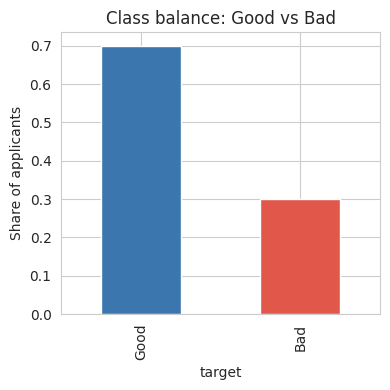

In [4]:
target_share = df['target'].value_counts(normalize=True).rename({0: 'Good', 1: 'Bad'})

fig, ax = plt.subplots(figsize=(4, 4))
target_share.plot(kind='bar', color=['#3B76AF', '#E1584B'], ax=ax)
ax.set_ylabel('Share of applicants')
ax.set_title('Class balance: Good vs Bad')
plt.tight_layout()
plt.show()

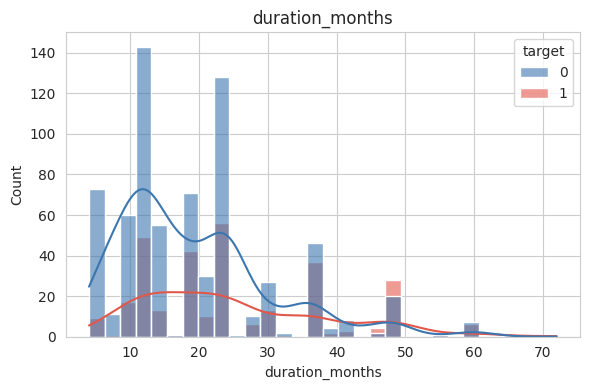

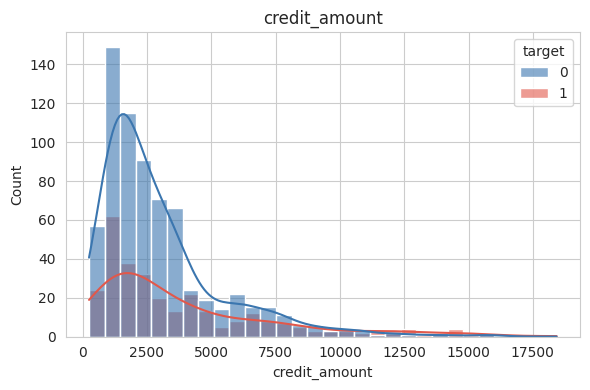

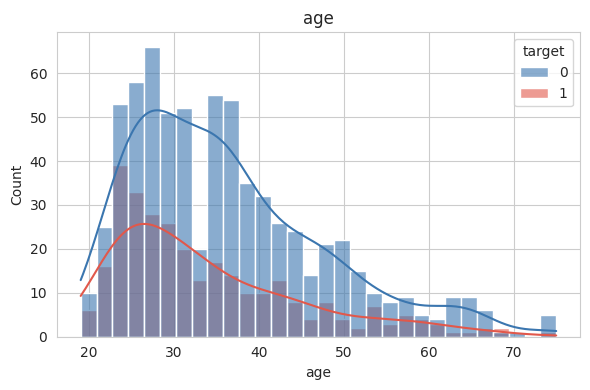

,duration_months,credit_amount,age
count,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,35.546000
std,12.058814,2822.736876,11.375469
min,4.000000,250.000000,19.000000
25%,12.000000,1365.500000,27.000000
50%,18.000000,2319.500000,33.000000
75%,24.000000,3972.250000,42.000000
max,72.000000,18424.000000,75.000000


In [5]:
for col in NUMERIC_FEATS[:3]:  # duration, credit_amount, age — the headline numeric features
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax,
                 palette={0: '#3B76AF', 1: '#E1584B'}, bins=30, alpha=0.6)
    ax.set_title(col)
    plt.tight_layout()
    plt.show()

df[['duration_months', 'credit_amount', 'age']].describe()

In [6]:
for col in ['checking_status', 'credit_history', 'purpose']:
    ct = pd.crosstab(df[col], df['target'], normalize='index').rename(
        columns={0: 'good_rate', 1: 'bad_rate'})
    ct = ct.sort_values('bad_rate', ascending=False)
    print(f'\n--- {col} vs target (row-normalized) ---')
    print(ct)


--- checking_status vs target (row-normalized) ---
target               good_rate  bad_rate
checking_status                         
< 0 DM                0.507299  0.492701
0-200 DM              0.609665  0.390335
>= 200 DM             0.777778  0.222222
no checking account   0.883249  0.116751

--- credit_history vs target (row-normalized) ---
target                                      good_rate  bad_rate
credit_history                                                 
no credits taken / all paid duly             0.375000  0.625000
all credits at this bank paid duly           0.428571  0.571429
existing credits paid duly till now          0.681132  0.318868
delay in paying off in the past              0.681818  0.318182
critical account / other credits elsewhere   0.829352  0.170648

--- purpose vs target (row-normalized) ---
target               good_rate  bad_rate
purpose                                 
education             0.560000  0.440000
others                0.583333  0.41

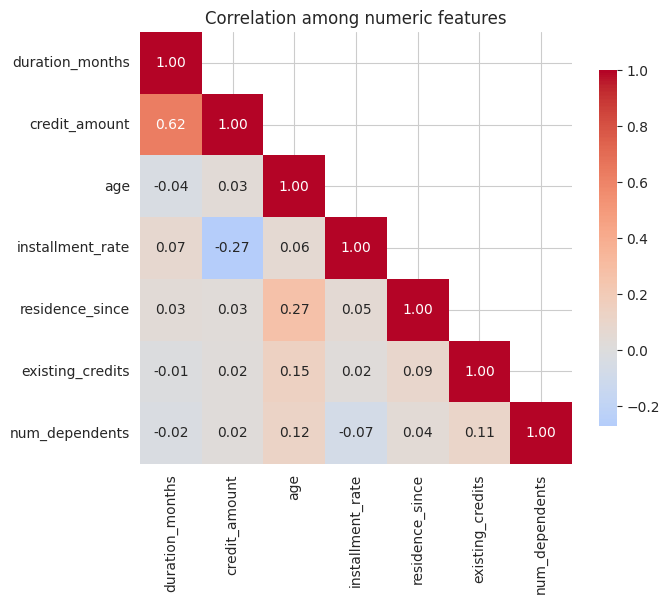

In [7]:
corr = df[NUMERIC_FEATS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation among numeric features')
plt.tight_layout()
plt.show()

**Reading the EDA:** applicants with no checking account or a strongly negative one, a
critical/no-credit-history record, and higher-risk purposes (used cars, "others") show
visibly higher bad rates. The numeric features are only weakly correlated with each other
(no severe multicollinearity risk going into modeling). `duration_months` and
`credit_amount` are positively correlated, which makes sense — longer loans tend to be for
larger amounts.

## 3. WOE/IV — full-data report

Before modeling, we compute **Weight of Evidence (WOE)** and **Information Value (IV)** for
every feature against the target, on the *full* dataset, purely to rank features for the
interpretability narrative below. This is a reporting step, not a modeling step — the
scorecard pipeline in Section 4 re-derives its own WOE bins and its own feature selection
**inside cross-validation**, on training folds only, so nothing here leaks into a
performance number.

- IV < 0.02 → too weak to be useful
- 0.02–0.1 → moderate
- 0.1–0.3 → strong
- \> 0.3 → very strong (worth a sanity check that it isn't a leak)

In [8]:
def calc_woe_iv(data: pd.DataFrame, feature: str, target: str, bins=None, is_numeric=False):
    '''Return (woe_table, iv_total) for a single feature.
    Good = target==0, Bad = target==1. Higher WOE = safer bin (more Good relative to Bad).
    A small (0.5-count) Laplace smoothing avoids log(0) / div-by-zero in sparse bins.
    '''
    d = data[[feature, target]].copy()
    if is_numeric:
        d[feature] = pd.qcut(d[feature], q=bins, duplicates='drop')

    grouped = d.groupby(feature, observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good, total_bad = grouped['good'].sum(), grouped['bad'].sum()
    grouped['good_pct'] = (grouped['good'] + 0.5) / (total_good + 0.5 * len(grouped))
    grouped['bad_pct'] = (grouped['bad'] + 0.5) / (total_bad + 0.5 * len(grouped))

    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']
    grouped['bad_rate'] = grouped['bad'] / grouped['total']

    return grouped.reset_index(), grouped['iv'].sum()


def iv_strength(iv: float) -> str:
    if iv < 0.02: return 'weak (drop)'
    if iv < 0.1: return 'moderate'
    if iv < 0.3: return 'strong'
    return 'very strong (check)'


iv_results, woe_tables = {}, {}
for feat in NUMERIC_FEATS:
    tbl, iv = calc_woe_iv(df, feat, 'target', bins=5, is_numeric=True)
    iv_results[feat], woe_tables[feat] = iv, tbl
for feat in CATEGORICAL_FEATS:
    tbl, iv = calc_woe_iv(df, feat, 'target', is_numeric=False)
    iv_results[feat], woe_tables[feat] = iv, tbl

iv_report = pd.Series(iv_results).sort_values(ascending=False).rename('IV').to_frame()
iv_report['strength'] = iv_report['IV'].apply(iv_strength)
iv_report

,IV,strength
checking_status,0.659056,very strong (check)
credit_history,0.290832,strong
duration_months,0.213164,strong
savings_status,0.187938,strong
purpose,0.163613,strong
property,0.111799,strong
credit_amount,0.092127,moderate
employment_since,0.085656,moderate
housing,0.083800,moderate
age,0.067332,moderate


**Note on `checking_status` (IV ≈ 0.66):** this is the single strongest predictor by a
wide margin. It is *not* a leak — it's a genuinely strong, well-documented signal in this
dataset (whether an applicant has a checking account at all, and its balance, is a classic
early indicator of financial stability) — but an IV this high is always worth a second look
in a real deployment to rule out target leakage before trusting it blindly.

`job`, `telephone`, `existing_credits`, `residence_since`, and `num_dependents` fall below
the IV < 0.02 cutoff on the full data; Section 4's pipeline re-checks this per fold rather
than assuming it holds on every training subset.

## 4. Baseline model: Logistic Regression scorecard

The WOE encoder below is now a proper `sklearn` `BaseEstimator`/`TransformerMixin`: it has
`fit`/`transform`, drops low-IV features as part of `fit` (not as a separate step done once
beforehand), and slots into a `Pipeline` with `LogisticRegression`. That makes it usable with
`cross_val_score` / `cross_val_predict`, so "fit WOE bins on training data only" is enforced
automatically on every fold instead of relying on us remembering to split before encoding.

In [9]:
class WOETransformer(BaseEstimator, TransformerMixin):
    '''Weight-of-Evidence encoder for numeric + categorical features.

    Fits bin edges / WOE maps on whatever data it sees in `fit` — the training fold only,
    when used inside cross_val_score/Pipeline, which is what keeps it leakage-safe.
    Features whose training-fold IV falls below `min_iv` are dropped from the output, so
    feature selection happens *inside* the CV loop rather than once on the full data.
    '''

    def __init__(self, numeric_feats, categorical_feats, n_bins=5, min_iv=0.02):
        self.numeric_feats = numeric_feats
        self.categorical_feats = categorical_feats
        self.n_bins = n_bins
        self.min_iv = min_iv

    @staticmethod
    def _woe_table(binned_series, y):
        d = pd.DataFrame({'bin': binned_series, 'y': np.asarray(y)})
        grouped = d.groupby('bin', observed=True)['y'].agg(['count', 'sum'])
        grouped.columns = ['total', 'bad']
        grouped['good'] = grouped['total'] - grouped['bad']
        total_good, total_bad = grouped['good'].sum(), grouped['bad'].sum()
        grouped['good_pct'] = (grouped['good'] + 0.5) / (total_good + 0.5 * len(grouped))
        grouped['bad_pct'] = (grouped['bad'] + 0.5) / (total_bad + 0.5 * len(grouped))
        grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
        grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']
        return grouped

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        self.bin_edges_, self.woe_maps_, self.iv_ = {}, {}, {}

        for feat in self.numeric_feats:
            try:
                _, edges = pd.qcut(X[feat], q=self.n_bins, duplicates='drop', retbins=True)
            except ValueError:
                _, edges = pd.qcut(X[feat], q=3, duplicates='drop', retbins=True)
            edges = edges.copy()
            edges[0], edges[-1] = -np.inf, np.inf
            self.bin_edges_[feat] = edges
            binned = pd.cut(X[feat], bins=edges, include_lowest=True)
            tbl = self._woe_table(binned, y)
            self.woe_maps_[feat] = tbl['woe'].to_dict()
            self.iv_[feat] = tbl['iv'].sum()

        for feat in self.categorical_feats:
            tbl = self._woe_table(X[feat], y)
            self.woe_maps_[feat] = tbl['woe'].to_dict()
            self.iv_[feat] = tbl['iv'].sum()

        self.iv_summary_ = pd.Series(self.iv_).sort_values(ascending=False)
        self.keep_feats_ = self.iv_summary_[self.iv_summary_ >= self.min_iv].index.tolist()
        self.feature_names_out_ = [f + '_woe' for f in self.keep_feats_]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = pd.DataFrame(index=X.index)
        for feat in self.keep_feats_:
            if feat in self.numeric_feats:
                binned = pd.cut(X[feat], bins=self.bin_edges_[feat], include_lowest=True)
                out[feat + '_woe'] = binned.map(self.woe_maps_[feat]).astype(float).fillna(0.0)
            else:
                out[feat + '_woe'] = X[feat].map(self.woe_maps_[feat]).astype(float).fillna(0.0)
        return out[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

In [10]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CFG.test_size, random_state=CFG.random_state, stratify=y
)
print(X_train.shape, X_test.shape)

cv = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.random_state)

scorecard_pipe = Pipeline([
    ('woe', WOETransformer(NUMERIC_FEATS, CATEGORICAL_FEATS, n_bins=5, min_iv=CFG.min_iv)),
    ('clf', LogisticRegression(max_iter=2000)),
])

cv_aucs = cross_val_score(scorecard_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'Logistic scorecard {CFG.n_splits}-fold CV AUC: {cv_aucs.mean():.4f} +/- {cv_aucs.std():.4f}')
print('Per-fold AUCs:', np.round(cv_aucs, 4))

(750, 20) (250, 20)


Logistic scorecard 5-fold CV AUC: 0.7671 +/- 0.0351
Per-fold AUCs: [0.7056 0.7871 0.7922 0.8    0.7505]


**Why this matters:** a single 750/250 split gives one AUC number that can move by a
point or two just from which rows landed in the test set. The 5-fold mean +/- std above is
the more honest way to state "how good is this model" — and it's what we should quote if
asked, not the single held-out number below (which we still report, once, at the end, as the
final unbiased check on the model we ultimately fit).

In [11]:
scorecard_pipe.fit(X_train, y_train)
test_proba_lr = scorecard_pipe.predict_proba(X_test)[:, 1]
test_auc_lr = roc_auc_score(y_test, test_proba_lr)
print(f'Logistic scorecard — held-out test AUC: {test_auc_lr:.4f}')

woe_step = scorecard_pipe.named_steps['woe']
lr = scorecard_pipe.named_steps['clf']
print(f'Kept {len(woe_step.keep_feats_)} of {len(woe_step.iv_summary_)} features (IV >= {CFG.min_iv}, fit on train only)')
woe_step.iv_summary_

Logistic scorecard — held-out test AUC: 0.7995
Kept 16 of 20 features (IV >= 0.02, fit on train only)


checking_status            0.624314
credit_history             0.259934
savings_status             0.230510
duration_months            0.190452
property                   0.150028
purpose                    0.144816
employment_since           0.126575
other_installment_plans    0.092840
housing                    0.090245
credit_amount              0.070356
personal_status_sex        0.048486
foreign_worker             0.042420
age                        0.033802
installment_rate           0.029368
job                        0.021783
other_debtors              0.020383
telephone                  0.004784
residence_since            0.000265
existing_credits           0.000052
num_dependents             0.000000
dtype: float64

### Converting to a points-based scorecard (PDO scaling)

The model predicts `P(bad)`. We score on the **good:bad odds** using the standard industry
PDO (points-to-double-odds) formula:

```
factor = PDO / ln(2)
offset = base_score - factor * ln(base_odds)
ln(odds) = -(intercept + sum(coef_i * woe_i))
score   = offset + factor * ln(odds)
```

The intercept is split evenly across features so each feature's contribution (`points_i`)
sums exactly back to the total score — this is what makes the output an actual per-feature,
human-readable points table instead of just a probability. Everything below reads straight
off the fitted pipeline (`woe_step`, `lr`) rather than duplicating fit logic.

In [12]:
factor = CFG.pdo / np.log(2)
offset = CFG.base_score - factor * np.log(CFG.base_odds)

intercept = lr.intercept_[0]
coefs = dict(zip(woe_step.feature_names_out_, lr.coef_[0]))
n_feats = len(coefs)


def score_row(row: pd.Series) -> float:
    total = 0.0
    for col, coef in coefs.items():
        total += -(coef * row[col] + intercept / n_feats) * factor + offset / n_feats
    return total


X_train_woe = woe_step.transform(X_train)
X_test_woe = woe_step.transform(X_test)
train_scores = X_train_woe.apply(score_row, axis=1)

print('Train score distribution:')
print(train_scores.describe())

# Sanity check: per-feature points should sum exactly to the model-implied score
p_bad_train = lr.predict_proba(X_train_woe)[:, 1]
odds_good_bad = (1 - p_bad_train) / p_bad_train
implied_score = offset + factor * np.log(odds_good_bad)
print('\nMax abs diff between summed points and model-implied score:',
      (implied_score - train_scores).abs().max())

Train score distribution:
count    750.000000
mean     521.253301
std       40.989666
min      423.495929
25%      490.909303
50%      521.611457
75%      552.235901
max      638.807387
dtype: float64

Max abs diff between summed points and model-implied score: 2.2737367544323206e-13


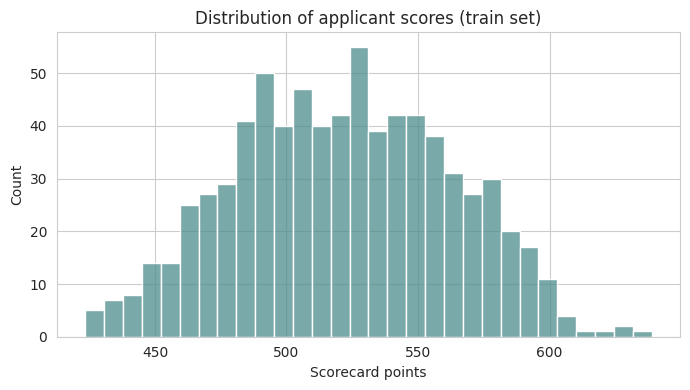

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train_scores, bins=30, color='#4C8C8C')
ax.set_xlabel('Scorecard points')
ax.set_title('Distribution of applicant scores (train set)')
plt.tight_layout()
plt.show()

In [14]:
coef_table = (pd.Series(coefs, name='coefficient')
              .sort_values()
              .rename_axis('feature')
              .reset_index())
coef_table

,feature,coefficient
0,installment_rate_woe,-1.385860
1,personal_status_sex_woe,-0.985521
2,purpose_woe,-0.889955
3,savings_status_woe,-0.878979
4,duration_months_woe,-0.831104
5,checking_status_woe,-0.779966
6,other_installment_plans_woe,-0.720136
7,foreign_worker_woe,-0.715873
8,credit_history_woe,-0.698965
9,employment_since_woe,-0.642072


**Reading the coefficients:** nearly all WOE coefficients are negative, which is the
expected sign — a higher WOE means a "safer" bin, and a negative coefficient on `ln(odds of
bad)` pushes predicted risk down, exactly as it should. Any feature with a small positive
coefficient despite a low IV is a sign of mild multicollinearity among the WOE features
rather than a real effect — in a production scorecard we'd drop it rather than let it flip
sign.

## 5. Comparison model: Gradient boosting (Optuna-tuned)

LightGBM on the same (raw, richer) features — no manual binning needed, it can find its own
splits. Hyperparameters are tuned with **Optuna**, optimizing mean 5-fold CV AUC on the
training set (same folds as the scorecard, for a fair comparison), instead of being
hand-picked. We keep the monotonic constraints (longer duration / larger credit amount →
non-decreasing risk; older age → non-increasing risk) fixed across trials so every candidate
model stays defensible, not just the fastest one.

In [15]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
cat_cols = X_train_lgb.select_dtypes(exclude='number').columns.tolist()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype('category')
    X_test_lgb[c] = X_test_lgb[c].astype('category')
    X_test_lgb[c] = X_test_lgb[c].cat.set_categories(X_train_lgb[c].cat.categories)

mono_map = {c: 0 for c in X_train_lgb.columns}
mono_map['duration_months'] = 1   # longer duration -> non-decreasing risk
mono_map['credit_amount'] = 1     # larger amount -> non-decreasing risk
mono_map['age'] = -1              # older -> non-increasing risk
mono_constraints = [mono_map[c] for c in X_train_lgb.columns]


def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
        max_depth=trial.suggest_int('max_depth', 3, 6),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 31),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
    )
    model = lgb.LGBMClassifier(
        **params, random_state=CFG.random_state, verbose=-1,
        monotone_constraints=mono_constraints,
    )
    fold_aucs = []
    for tr_idx, val_idx in cv.split(X_train_lgb, y_train):
        X_tr, X_val = X_train_lgb.iloc[tr_idx], X_train_lgb.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr, categorical_feature=cat_cols)
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return float(np.mean(fold_aucs))


study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=CFG.random_state))
study.optimize(objective, n_trials=CFG.n_optuna_trials, show_progress_bar=False)

print(f'Best CV AUC over {CFG.n_optuna_trials} Optuna trials: {study.best_value:.4f}')
print('Best params:', study.best_params)
print(f'(scorecard {CFG.n_splits}-fold CV AUC was {cv_aucs.mean():.4f} for comparison)')

Best CV AUC over 25 Optuna trials: 0.7700
Best params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.016043388127350112, 'num_leaves': 7, 'subsample': 0.8982068356429268, 'colsample_bytree': 0.6006968589403205, 'reg_lambda': 0.4573953893214972}
(scorecard 5-fold CV AUC was 0.7671 for comparison)


In [16]:
lgbm = lgb.LGBMClassifier(
    **study.best_params, random_state=CFG.random_state, verbose=-1,
    monotone_constraints=mono_constraints,
)
lgbm.fit(X_train_lgb, y_train, categorical_feature=cat_cols)

test_proba_lgb = lgbm.predict_proba(X_test_lgb)[:, 1]
test_auc_lgb = roc_auc_score(y_test, test_proba_lgb)
print(f'LightGBM (tuned) — held-out test AUC: {test_auc_lgb:.4f}')
print(f'(scorecard held-out test AUC was {test_auc_lr:.4f} for comparison)')

LightGBM (tuned) — held-out test AUC: 0.8089
(scorecard held-out test AUC was 0.7995 for comparison)


## 6. Evaluation

ROC-AUC and the **KS statistic** (the industry-standard separation measure in credit risk),
then a confusion matrix weighted by the dataset's **5:1 cost asymmetry** — this is the part
a generic classification write-up skips, and it changes the story: the best *threshold* is
not the same as the best *AUC*.

**On the threshold itself:** we pick the cost-minimizing threshold from **out-of-fold
predictions on the training set** (`cross_val_predict`), not by scanning thresholds against
the test set. Choosing a threshold by minimizing cost on the same test set we report
performance on would quietly overfit the threshold to that particular 250-row sample — the
test set is only touched once, at the end, to confirm the OOF-chosen threshold still looks
reasonable out of sample.

In [17]:
def ks_statistic(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    idx = np.argmax(np.abs(tpr - fpr))
    return np.abs(tpr - fpr)[idx], thresholds[idx]


for name, proba in [('Logistic scorecard', test_proba_lr), ('LightGBM (tuned)', test_proba_lgb)]:
    auc = roc_auc_score(y_test, proba)
    ks, ks_t = ks_statistic(y_test, proba)
    print(f'{name:22s} test AUC={auc:.4f}  KS={ks:.4f} (max separation at score threshold {ks_t:.4f})')

Logistic scorecard     test AUC=0.7995  KS=0.5086 (max separation at score threshold 0.3528)
LightGBM (tuned)       test AUC=0.8089  KS=0.4895 (max separation at score threshold 0.2932)


In [18]:
def cost_of_threshold(y_true, proba, threshold, cost_fn=CFG.cost_fn, cost_fp=CFG.cost_fp):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost, (tn, fp, fn, tp)


def find_cost_optimal_threshold(y_true, proba, cost_fn=CFG.cost_fn, cost_fp=CFG.cost_fp, grid=None):
    if grid is None:
        grid = np.linspace(0.02, 0.98, 97)
    costs = [cost_of_threshold(y_true, proba, t, cost_fn, cost_fp)[0] for t in grid]
    best_i = int(np.argmin(costs))
    return grid[best_i], costs[best_i]


def report_cost(y_true, proba, threshold, label, plot=True):
    total_cost, (tn, fp, fn, tp) = cost_of_threshold(y_true, proba, threshold)
    print(f'\n{label} @ threshold={threshold:.2f}')
    print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
    print(f'  Weighted cost = {fn}*{CFG.cost_fn:.0f} + {fp}*{CFG.cost_fp:.0f} = {total_cost:.0f}  '
          f'(avg cost/applicant = {total_cost/len(y_true):.3f})')
    if plot:
        pred = (proba >= threshold).astype(int)
        ConfusionMatrixDisplay(confusion_matrix(y_true, pred),
                                display_labels=['Good', 'Bad']).plot(cmap='Blues')
        plt.title(f'{label} @ threshold={threshold:.2f}')
        plt.show()
    return total_cost

Logistic scorecard: cost-optimal threshold from OOF train predictions = 0.17 (avg OOF cost/applicant = 0.539)

Logistic scorecard (default 0.5) @ threshold=0.50
  TN=156  FP=19  FN=40  TP=35
  Weighted cost = 40*5 + 19*1 = 219  (avg cost/applicant = 0.876)

Logistic scorecard (OOF-selected threshold, applied to test once) @ threshold=0.17
  TN=96  FP=79  FN=10  TP=65
  Weighted cost = 10*5 + 79*1 = 129  (avg cost/applicant = 0.516)


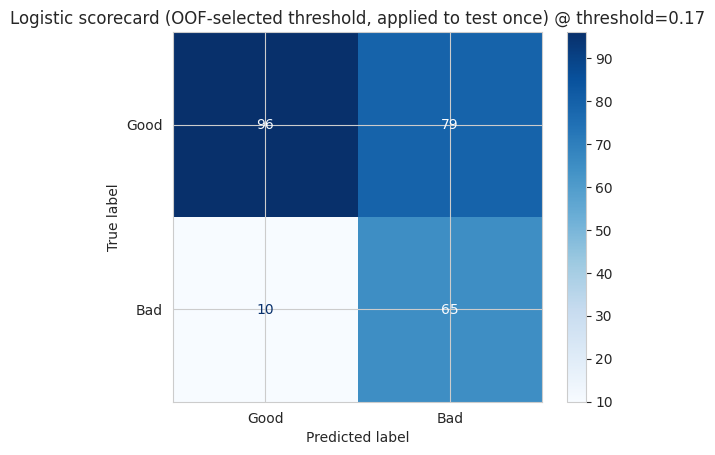

LightGBM (tuned): cost-optimal threshold from OOF train predictions = 0.11 (avg OOF cost/applicant = 0.555)

LightGBM (tuned) (default 0.5) @ threshold=0.50
  TN=152  FP=23  FN=37  TP=38
  Weighted cost = 37*5 + 23*1 = 208  (avg cost/applicant = 0.832)

LightGBM (tuned) (OOF-selected threshold, applied to test once) @ threshold=0.11
  TN=71  FP=104  FN=3  TP=72
  Weighted cost = 3*5 + 104*1 = 119  (avg cost/applicant = 0.476)


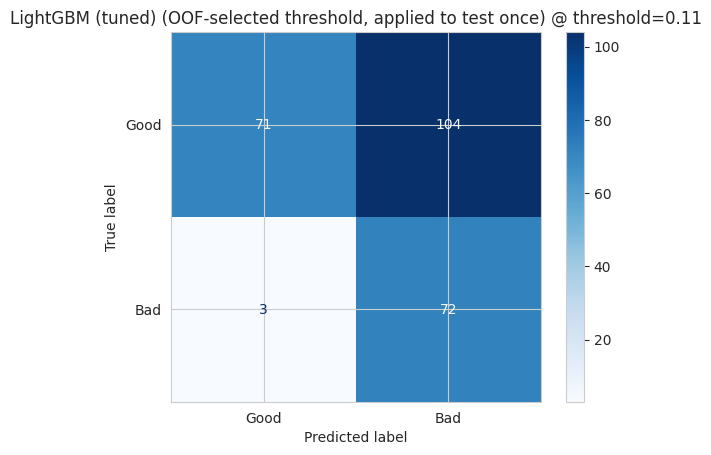

In [19]:
# Out-of-fold probabilities on the training set, used only to pick the threshold —
# never to report performance.
oof_proba_lr = cross_val_predict(scorecard_pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
oof_proba_lgb = cross_val_predict(
    lgb.LGBMClassifier(**study.best_params, random_state=CFG.random_state, verbose=-1,
                        monotone_constraints=mono_constraints),
    X_train_lgb, y_train, cv=cv, method='predict_proba',
    params={'categorical_feature': cat_cols},
)[:, 1]

thresholds = {}
for name, oof_proba, test_proba in [
    ('Logistic scorecard', oof_proba_lr, test_proba_lr),
    ('LightGBM (tuned)', oof_proba_lgb, test_proba_lgb),
]:
    best_t, best_oof_cost = find_cost_optimal_threshold(y_train, oof_proba)
    thresholds[name] = best_t
    print(f'{name}: cost-optimal threshold from OOF train predictions = {best_t:.2f} '
          f'(avg OOF cost/applicant = {best_oof_cost/len(y_train):.3f})')

    report_cost(y_test, test_proba, 0.5, f'{name} (default 0.5)', plot=False)
    report_cost(y_test, test_proba, best_t, f'{name} (OOF-selected threshold, applied to test once)')

**Takeaway:** at the default 0.5 cutoff both models look similar and fairly conservative
(few applicants flagged as bad, but a costly number of missed defaults). Moving to the
OOF-selected threshold meaningfully lowers the weighted cost for both models by approving
fewer borderline applicants — the AUC/KS gap between the scorecard and tuned LightGBM is
small, but the **threshold choice** matters far more to the business than which of these two
models you pick.

## 7. Explainability layer

SHAP values for the tuned LightGBM model — global feature importance plus individual
applicant explanations — cross-checked against the scorecard's own coefficients, plus a
worked example of turning the top negative contributors into human-readable **reason codes**
(mirroring the adverse-action notice requirements under ECOA / Reg B).

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


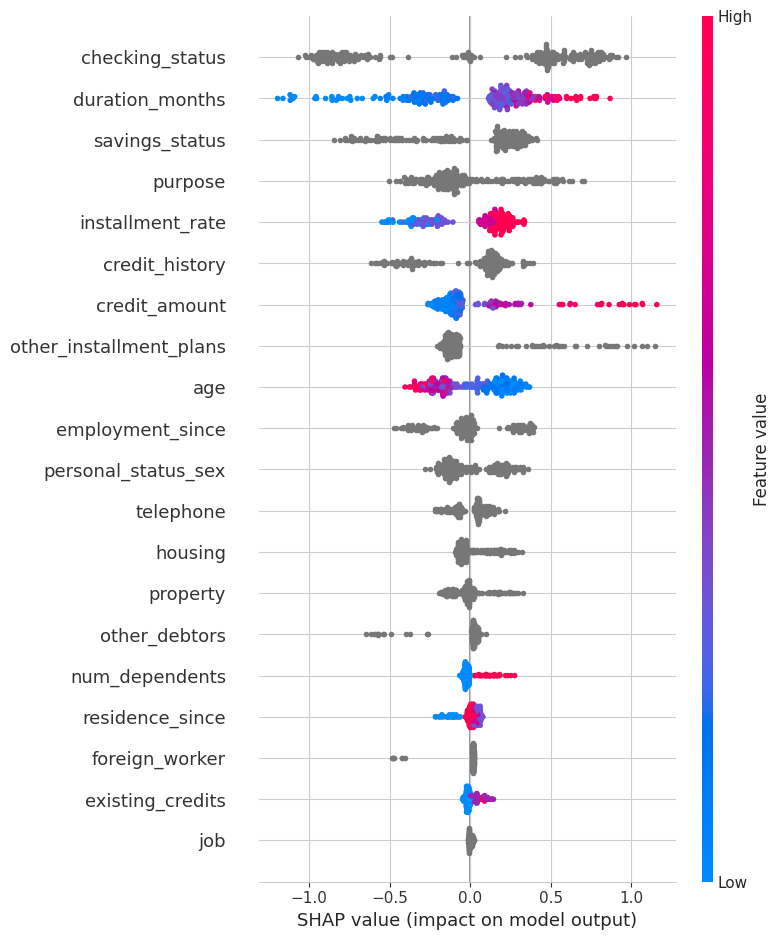

In [20]:
explainer = shap.TreeExplainer(lgbm)
shap_values_raw = explainer.shap_values(X_test_lgb)
# Handle both TreeExplainer output conventions across SHAP versions for binary classifiers.
sv = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw

shap.summary_plot(sv, X_test_lgb, show=False)
plt.tight_layout()
plt.show()

In [21]:
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_test_lgb.columns).sort_values(ascending=False)
print('Global SHAP importance (mean |SHAP value|):')
mean_abs_shap

Global SHAP importance (mean |SHAP value|):


checking_status            0.647457
duration_months            0.370053
savings_status             0.304235
purpose                    0.229053
installment_rate           0.222375
credit_history             0.216692
credit_amount              0.194560
other_installment_plans    0.193168
age                        0.191522
employment_since           0.162339
personal_status_sex        0.148003
telephone                  0.086651
housing                    0.082157
property                   0.075434
other_debtors              0.057009
num_dependents             0.038790
residence_since            0.038519
foreign_worker             0.031999
existing_credits           0.028200
job                        0.007244
dtype: float64

In [22]:
# Cross-check SHAP ranking against the scorecard's |coefficient| ranking -- do they agree?
coef_abs = pd.Series({c.replace('_woe', ''): abs(v) for c, v in coefs.items()})
compare = pd.DataFrame({
    'shap_rank': mean_abs_shap.rank(ascending=False),
    'scorecard_rank': coef_abs.rank(ascending=False),
}).dropna().sort_values('shap_rank')
compare['rank_diff'] = (compare['shap_rank'] - compare['scorecard_rank']).abs()
print('Spearman rank correlation between SHAP and scorecard feature rankings:',
      round(compare['shap_rank'].corr(compare['scorecard_rank'], method='spearman'), 3))
compare

Spearman rank correlation between SHAP and scorecard feature rankings: 0.618


,shap_rank,scorecard_rank,rank_diff
checking_status,1.0,6.0,5.0
duration_months,2.0,5.0,3.0
savings_status,3.0,4.0,1.0
purpose,4.0,3.0,1.0
installment_rate,5.0,1.0,4.0
credit_history,6.0,9.0,3.0
credit_amount,7.0,12.0,5.0
other_installment_plans,8.0,7.0,1.0
age,9.0,13.0,4.0
employment_since,10.0,10.0,0.0


In [23]:
def reason_codes(applicant_idx: int, top_k: int = 3):
    '''Top-k features pushing this applicant's risk UP, as adverse-action-style reason codes.'''
    feat_impact = pd.Series(sv[applicant_idx], index=X_test_lgb.columns)
    top_bad = feat_impact.sort_values(ascending=False).head(top_k)
    codes = []
    for feat, val in top_bad.items():
        raw_val = X_test_lgb.iloc[applicant_idx][feat]
        codes.append(f'{feat} = {raw_val} (contributed +{val:.3f} to predicted risk)')
    return codes


for idx in [0, 5]:
    print(f'\nApplicant {idx} — top reasons for elevated risk score:')
    for c in reason_codes(idx):
        print(' -', c)


Applicant 0 — top reasons for elevated risk score:
 - duration_months = 48 (contributed +0.772 to predicted risk)
 - checking_status = < 0 DM (contributed +0.767 to predicted risk)
 - credit_history = no credits taken / all paid duly (contributed +0.372 to predicted risk)

Applicant 5 — top reasons for elevated risk score:
 - checking_status = < 0 DM (contributed +0.800 to predicted risk)
 - duration_months = 36 (contributed +0.519 to predicted risk)
 - savings_status = < 100 DM (contributed +0.351 to predicted risk)


**Agreement check:** the two explanation methods broadly agree on the top handful of
drivers (`checking_status`, `duration_months`, `savings_status`, `credit_history` tend to
show up near the top of both rankings), but the Spearman correlation is only moderate — a
few features rank noticeably differently between the linear scorecard and the boosted
model's SHAP values, most likely because the tree model captures interaction effects the
linear scorecard can't. That divergence is itself useful documentation: it tells a reviewer
where the two models would disagree about *why* an applicant was flagged, not just
whether.

## 8. Fairness check

Not a full audit — just enough to show fairness is being tracked as a risk-model concern. We
look at approval-rate and actual-default-rate disparities across age bands and
`personal_status_sex` (present in this dataset), using the LightGBM model at its
**OOF-selected threshold** (Section 6) rather than the arbitrary 0.5 cutoff, and apply the
informal **four-fifths rule** as a rough screen.

In [24]:
fairness_threshold = thresholds['LightGBM (tuned)']
pred_bad = (test_proba_lgb >= fairness_threshold).astype(int)

fairness_df = X_test.reset_index(drop=True).copy()
fairness_df['actual_bad'] = y_test.reset_index(drop=True)
fairness_df['pred_bad'] = pred_bad
fairness_df['approved'] = 1 - pred_bad

age_bins = [17, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56+']
fairness_df['age_band'] = pd.cut(fairness_df['age'], bins=age_bins, labels=age_labels)

age_report = fairness_df.groupby('age_band', observed=True).agg(
    n=('approved', 'size'), approval_rate=('approved', 'mean'),
    actual_default_rate=('actual_bad', 'mean'), model_flagged_bad_rate=('pred_bad', 'mean'),
)
print(f'=== By age band (threshold={fairness_threshold:.2f}) ===')
print(age_report)

sex_report = fairness_df.groupby('personal_status_sex', observed=True).agg(
    n=('approved', 'size'), approval_rate=('approved', 'mean'),
    actual_default_rate=('actual_bad', 'mean'), model_flagged_bad_rate=('pred_bad', 'mean'),
)
print('\n=== By personal_status_sex ===')
print(sex_report)

=== By age band (threshold=0.11) ===
           n  approval_rate  actual_default_rate  model_flagged_bad_rate
age_band                                                                
18-25     54       0.111111             0.500000                0.888889
26-35     87       0.241379             0.287356                0.758621
36-45     58       0.465517             0.241379                0.534483
46-55     28       0.392857             0.214286                0.607143
56+       23       0.391304             0.130435                0.608696

=== By personal_status_sex ===
                                      n  approval_rate  actual_default_rate  \
personal_status_sex                                                           
female: divorced/separated/married   78       0.192308             0.346154   
male: divorced/separated             10       0.100000             0.400000   
male: married/widowed                23       0.260870             0.260870   
male: single             

In [25]:
def four_fifths_ratios(rates: pd.Series) -> pd.Series:
    return (rates / rates.max()).rename('ratio_to_max_group')

print('Four-fifths rule ratios — age bands (< 0.8 = worth reviewing):')
print(four_fifths_ratios(age_report['approval_rate']))
print('\nFour-fifths rule ratios — personal_status_sex (< 0.8 = worth reviewing):')
print(four_fifths_ratios(sex_report['approval_rate']))

Four-fifths rule ratios — age bands (< 0.8 = worth reviewing):
age_band
18-25    0.238683
26-35    0.518519
36-45    1.000000
46-55    0.843915
56+      0.840580
Name: ratio_to_max_group, dtype: float64

Four-fifths rule ratios — personal_status_sex (< 0.8 = worth reviewing):
personal_status_sex
female: divorced/separated/married    0.514053
male: divorced/separated              0.267308
male: married/widowed                 0.697324
male: single                          1.000000
Name: ratio_to_max_group, dtype: float64


**Reading the fairness check:** younger applicants (18-35) get approved at a noticeably
lower rate than older ones — which lines up with a real difference in actual default rate by
age in this data, so it's plausibly a legitimate risk signal rather than pure bias, but it's
exactly the kind of pattern a fair-lending review would want documented. The
`personal_status_sex` breakdown is noisier (some groups are tiny in a 250-row test set) and
one small group can fall below the four-fifths threshold; with a group that size this is more
likely sampling noise than a reliable disparity, but it's flagged here as something a larger
holdout sample would need to confirm before drawing conclusions. This section is a screen,
not a compliance determination — a real fair-lending review would need a statistician and
legal counsel.

## 9. Deliverable — model documentation summary

**Narrative:** EDA showed the target is moderately imbalanced (70/30 good/bad) and that
checking-account status, credit history, and loan purpose visibly separate the classes.
WOE/IV picked out the majority of features as informative (IV ≥ 0.02) and flagged
`checking_status` as an unusually strong single predictor worth double-checking for leakage
before production use. The WOE-transformed logistic regression converts cleanly into a
scorecard analysts can read feature-by-feature, and its performance is now reported as a
5-fold cross-validated AUC rather than a single split, so it's a more honest estimate of how
it'll generalize. Optuna-tuned LightGBM adds a modest AUC improvement over that scorecard —
itself a useful finding, since most of the recoverable signal in this dataset looks
linear/monotonic, so the extra opacity of a boosted model may not be worth it unless the
interaction effects SHAP surfaced turn out to matter operationally. Cost-weighted evaluation,
with the threshold chosen from out-of-fold training predictions rather than the test set
itself, showed the default 0.5 threshold is not the cost-minimizing one — both models should
be deployed at a lower cutoff given the 5:1 penalty on missed defaults. SHAP and the
scorecard broadly agree on top drivers, giving some confidence the boosted model isn't
relying on something spurious, and per-applicant reason codes are ready to be wired into
adverse-action notices. Age-band disparities look plausibly explainable by real
default-rate differences in the data, but should be documented and monitored in production;
the `personal_status_sex` disparity is based on small subgroup counts and needs a larger
sample before it's actionable either way.

**Recommendation:** ship the WOE/logistic scorecard as the primary, auditable decision
engine; keep tuned LightGBM as a challenger model / early-warning signal on the interaction
effects it uniquely captures, at a cost-calibrated (not default 0.5) threshold chosen from
out-of-fold predictions, with the fairness metrics above tracked as ongoing monitoring
rather than a one-time check.

### Optional: lightweight scoring function for a live demo

A minimal function that takes one applicant's raw feature values and returns a scorecard
score plus the top-3 SHAP-based reason codes — this is what a Gradio/Streamlit form would
call under the hood. It now calls straight into the fitted `scorecard_pipe` (`woe_step`,
`lr`, `score_row`) instead of re-deriving anything, so there's exactly one place each piece
of scoring logic lives.

In [26]:
def score_applicant(applicant_raw: dict) -> dict:
    '''applicant_raw: dict of {column_name: value} for all 20 raw feature columns
    (see COLUMNS above, minus target_raw). Returns the scorecard points and top reason codes.
    '''
    row = pd.DataFrame([applicant_raw])
    row_woe = woe_step.transform(row)
    score = score_row(row_woe.iloc[0])
    proba_bad = lr.predict_proba(row_woe)[0, 1]

    row_lgb = row.copy()
    for c in cat_cols:
        row_lgb[c] = pd.Categorical([row_lgb[c].iloc[0]], categories=X_train_lgb[c].cat.categories)
    row_sv = explainer.shap_values(row_lgb)
    row_sv = row_sv[1] if isinstance(row_sv, list) else row_sv
    impact = pd.Series(row_sv[0], index=row_lgb.columns).sort_values(ascending=False).head(3)
    reasons = [f'{f} = {row_lgb.iloc[0][f]}' for f in impact.index]

    return {'scorecard_points': round(score, 1), 'p_bad': round(float(proba_bad), 3), 'top_reasons': reasons}


# Example call using an existing test-set applicant
example_applicant = X_test.iloc[0].to_dict()
score_applicant(example_applicant)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


{'scorecard_points': np.float64(433.2),
 'p_bad': 0.866,
 'top_reasons': ['duration_months = 48',
  'checking_status = < 0 DM',
  'credit_history = no credits taken / all paid duly']}